# 03 – Missing Value Analysis and Imputation

This notebook:
- Visualizes missing data patterns.
- Splits the dataset into two logical parts based on study participation.
- Applies different imputation strategies:
  - **Mean imputation** for missing values in part 1 (MCAR).
  - **MICE (Iterative Imputer)** for missing values in part 2 (MNAR).

The result is a fully imputed, ready-to-encode dataset.

In [1]:
# --- Import libraries ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from google.colab import drive
import os

In [2]:
# --- Mount Google Drive and set project paths ---
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/classification_project'
data_path = f'{base_path}/data'
results_path = f'{base_path}/results'
os.makedirs(data_path, exist_ok=True)
os.makedirs(results_path, exist_ok=True)

Mounted at /content/drive


In [3]:
# --- Load dataset ---
file_path = f'{data_path}/02_log_transformed_cirrhosis.csv'
cirrhosis_log_transformed = pd.read_csv(file_path)
print(f"Dataset loaded successfully from: {file_path}")
print("Shape:", cirrhosis_log_transformed.shape)

Dataset loaded successfully from: /content/drive/MyDrive/classification_project/data/02_log_transformed_cirrhosis.csv
Shape: (418, 19)


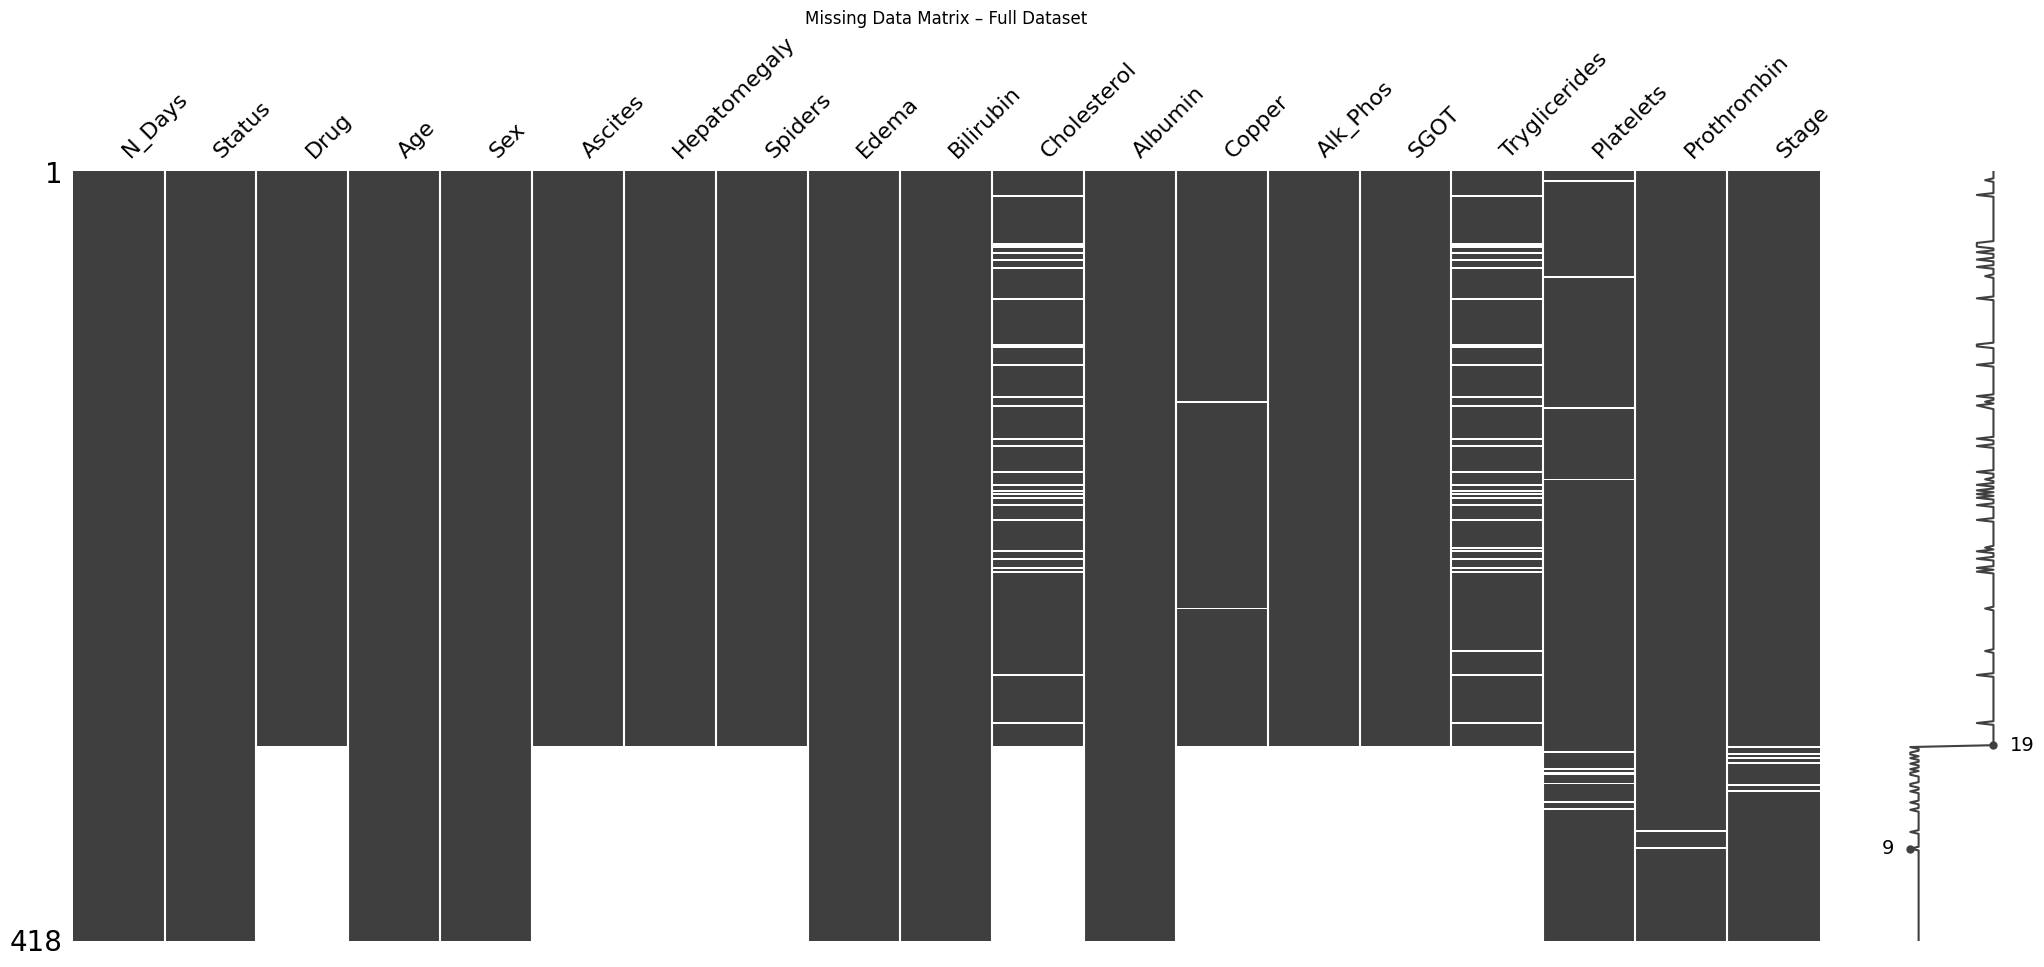

In [4]:
# --- Visualize overall missingness ---
msno.matrix(cirrhosis_log_transformed)
plt.title("Missing Data Matrix – Full Dataset")
plt.savefig(f"{results_path}/03_missing_matrix_full.png", bbox_inches='tight')
plt.show()

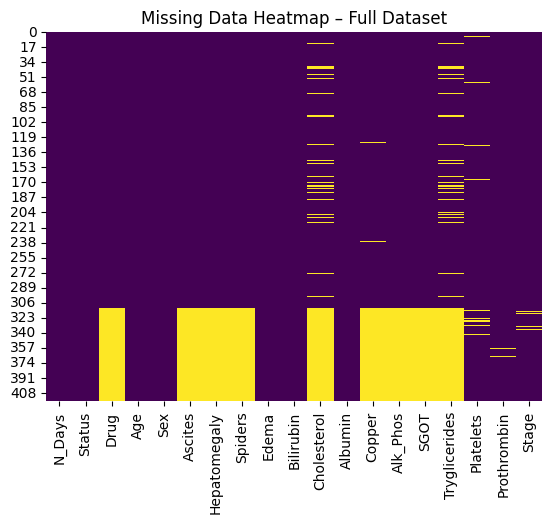

In [5]:
sns.heatmap(cirrhosis_log_transformed.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap – Full Dataset")
plt.savefig(f"{results_path}/03_missing_heatmap_full.png", bbox_inches='tight')
plt.show()

### Splitting the Dataset

We divide the dataset into two parts based on the study description:
- **Part 1 (first 312 records):** participants with moderate missing values (MCAR).
- **Part 2 (remaining 106 records):** follow-up cases with MNAR missingness.

In [6]:
# --- Split dataset into two parts ---
part1 = cirrhosis_log_transformed.iloc[0:312]
part2 = cirrhosis_log_transformed.iloc[312:]

print("Part 1 shape:", part1.shape)
print("Part 2 shape:", part2.shape)

Part 1 shape: (312, 19)
Part 2 shape: (106, 19)


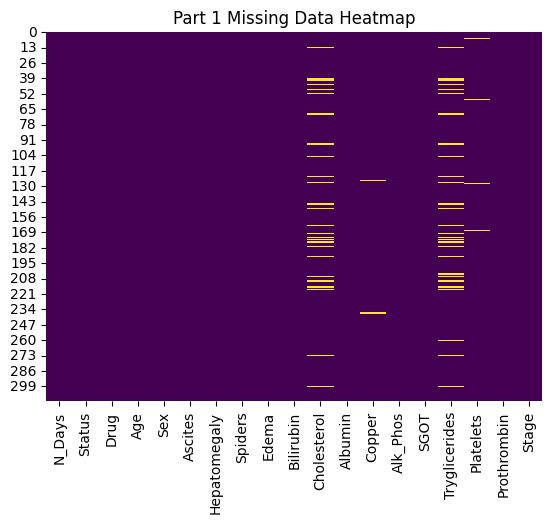

In [7]:
# --- Missing data inspection: Part 1 ---
sns.heatmap(part1.isnull(), cbar=False, cmap="viridis")
plt.title("Part 1 Missing Data Heatmap")
plt.savefig(f"{results_path}/03_part1_missing_heatmap.png", bbox_inches='tight')
plt.show()

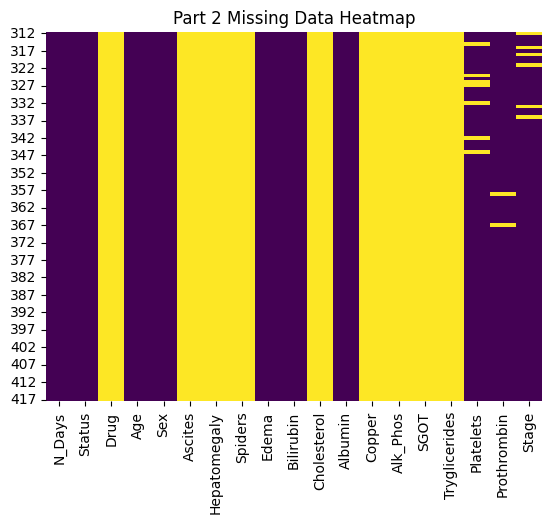

In [8]:
# --- Missing data inspection: Part 2 ---
sns.heatmap(part2.isnull(), cbar=False, cmap="viridis")
plt.title("Part 2 Missing Data Heatmap")
plt.savefig(f"{results_path}/03_part2_missing_heatmap.png", bbox_inches='tight')
plt.show()

### Part 1 – Mean Imputation (MCAR)

The first 312 records show random missingness in:
- **Cholesterol**
- **Copper**
- **Tryglicerides**
- **Platelets**

Visual analysis indicates the missingness is *not correlated* with target variable `Status`,
so we treat it as **MCAR** and impute using **Mean**.


/tmp/ipython-input-931032033.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  part1['Cholesterol_missing'] = part1['Cholesterol'].isnull()
/tmp/ipython-input-931032033.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  part1['Tryglicerides_missing'] = part1['Tryglicerides'].isnull()


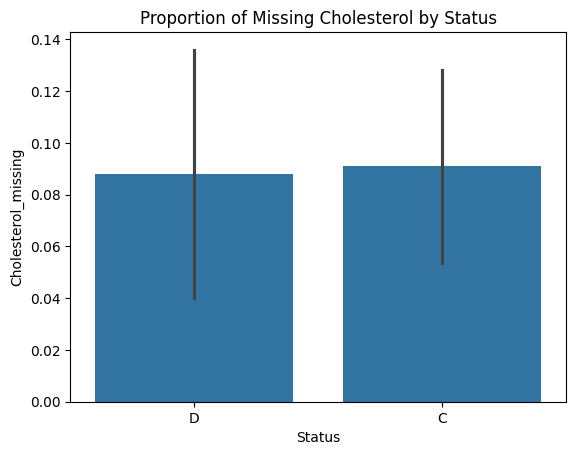

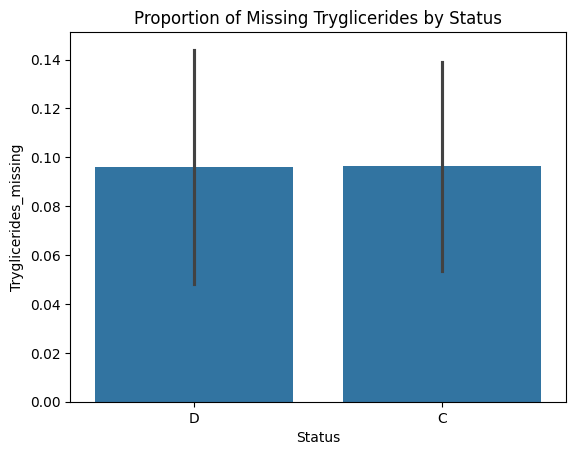

In [9]:
# --- Check correlation of missingness with Status (MCAR check) ---
part1['Cholesterol_missing'] = part1['Cholesterol'].isnull()
part1['Tryglicerides_missing'] = part1['Tryglicerides'].isnull()

sns.barplot(x='Status', y='Cholesterol_missing', data=part1)
plt.title('Proportion of Missing Cholesterol by Status')
plt.savefig(f"{results_path}/03_missing_cholesterol_by_status.png", bbox_inches='tight')
plt.show()

sns.barplot(x='Status', y='Tryglicerides_missing', data=part1)
plt.title('Proportion of Missing Tryglicerides by Status')
plt.savefig(f"{results_path}/03_missing_tryglicerides_by_status.png", bbox_inches='tight')
plt.show()

/tmp/ipython-input-3822322374.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  part1.drop(columns=['Cholesterol_missing', 'Tryglicerides_missing'], inplace=True)
/tmp/ipython-input-3822322374.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  part1[col] = mean_imputer.fit_transform(part1[[col]])
/tmp/ipython-input-3822322374.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

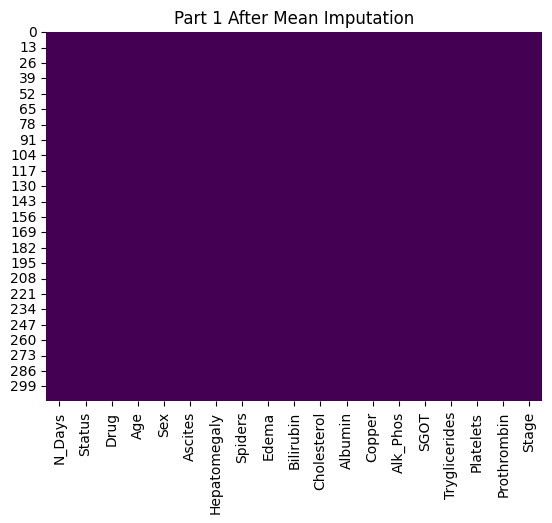

In [10]:
# --- Drop temporary flags ---
part1.drop(columns=['Cholesterol_missing', 'Tryglicerides_missing'], inplace=True)

# --- Mean Imputation for Part 1 (MCAR) ---
mean_imputer = SimpleImputer(strategy='mean')
for col in ['Cholesterol', 'Copper', 'Tryglicerides', 'Platelets']:
    part1[col] = mean_imputer.fit_transform(part1[[col]])

sns.heatmap(part1.isnull(), cbar=False, cmap="viridis")
plt.title("Part 1 After Mean Imputation")
plt.savefig(f"{results_path}/03_part1_after_mean_imputation.png", bbox_inches='tight')
plt.show()

### Part 2 – MICE Imputation (MNAR)

The second part (last 106 records) represents cases with non-random missingness (MNAR).  
We apply **MICE (Multiple Imputation by Chained Equations)** to estimate missing values iteratively.


In [11]:
# --- Combine and Encode for MICE ---
combined = pd.concat([part1, part2], axis=0).reset_index(drop=True)

combined['Status'].replace({'C': 0, 'D': 1}, inplace=True)
combined['Drug'].replace({'D-penicillamine': 0, 'Placebo': 1}, inplace=True)
combined['Sex'].replace({'M': 0, 'F': 1}, inplace=True)
combined['Ascites'].replace({'N': 0, 'Y': 1}, inplace=True)
combined['Hepatomegaly'].replace({'N': 0, 'Y': 1}, inplace=True)
combined['Spiders'].replace({'N': 0, 'Y': 1}, inplace=True)
combined['Edema'].replace({'N': 0, 'S': 1, 'Y': 2}, inplace=True)

/tmp/ipython-input-165586440.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined['Status'].replace({'C': 0, 'D': 1}, inplace=True)
/tmp/ipython-input-165586440.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined['Status'].replace({'C': 0, 'D': 1}, inplace=True)
/tmp/ipython-input-1

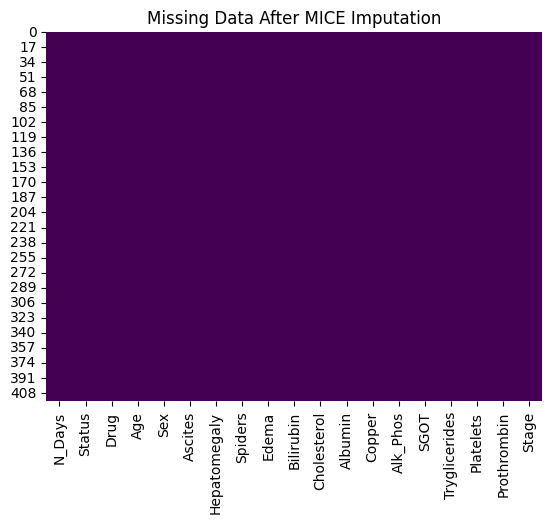

In [12]:
# --- MICE Imputation for Part 2 (MNAR) ---
mice_imputer = IterativeImputer(max_iter=10, random_state=0)
cols_for_mice = [
    'Drug', 'Ascites', 'Hepatomegaly', 'Spiders',
    'Cholesterol', 'Copper', 'Alk_Phos', 'SGOT',
    'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage'
]
combined[cols_for_mice] = mice_imputer.fit_transform(combined[cols_for_mice])

sns.heatmap(combined.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data After MICE Imputation")
plt.savefig(f"{results_path}/03_after_MICE_imputation.png", bbox_inches='tight')
plt.show()

In [13]:
# --- Save imputed dataset for next stage ---
save_path = f"{data_path}/03_cirrhosis_imputed.csv"
combined.to_csv(save_path, index=False)
print(f"Imputed dataset saved to: {save_path}")
print(f"All figures saved under: {results_path}")

Imputed dataset saved to: /content/drive/MyDrive/classification_project/data/03_cirrhosis_imputed.csv
All figures saved under: /content/drive/MyDrive/classification_project/results


**Next Notebook:** [04_Data_Encoding_and_Visualization.ipynb](04_Data_Encoding_and_Visualization.ipynb)

We will visualize the imputed dataset, explore categorical distributions, and study correlations between variables.
